In [5]:
!pip install torch torchvision numpy pandas matplotlib seaborn scikit-learn tqdm medmnist pytorch-fid pyarrow opencv-python

In [41]:
import os
import gc
import json
import time
import subprocess
import urllib.request
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms.functional import resize
from torchvision.utils import make_grid, save_image

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import medmnist
from medmnist import INFO

from pytorch_fid.fid_score import calculate_fid_given_paths

# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Part 1: Building and Understanding GANs from Scratch


### 1.1 Sine Wave GAN (Reproduction)

Epoch 0 | D Loss: 1.3711 | G Loss: 0.6780
Epoch 500 | D Loss: 1.4922 | G Loss: 0.5570
Epoch 1000 | D Loss: 1.3014 | G Loss: 0.7061
Epoch 1500 | D Loss: 1.3601 | G Loss: 0.6265
Epoch 2000 | D Loss: 1.3318 | G Loss: 0.7739
Epoch 2500 | D Loss: 1.4008 | G Loss: 0.7671


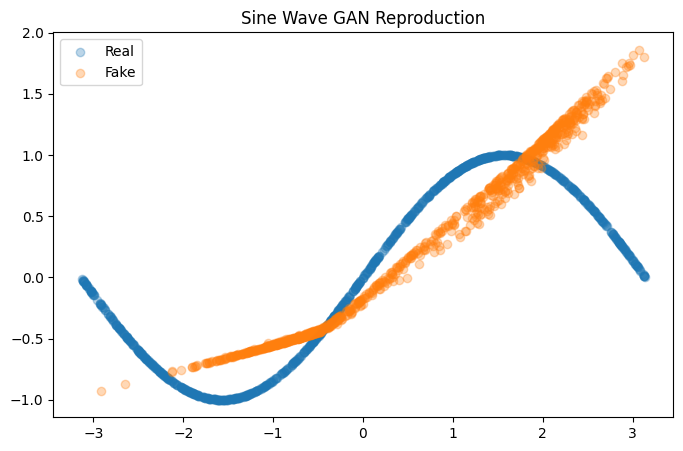

In [7]:
# generate synthetic sine wave data
def generate_sine_data(n=1000):
    x = np.random.uniform(-np.pi, np.pi, n)
    y = np.sin(x)
    return torch.tensor(np.stack([x, y], axis=1), dtype=torch.float32)

class Generator(nn.Module):
    def __init__(self, z_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# training
def train_gan(data, epochs=3000, batch_size=256):
    G = Generator().to(device)
    D = Discriminator().to(device)

    criterion = nn.BCELoss()
    g_opt = optim.Adam(G.parameters(), lr=0.001)
    d_opt = optim.Adam(D.parameters(), lr=0.001)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    for epoch in range(epochs):
        idx = torch.randint(0, data.shape[0], (batch_size,))
        real = data[idx].to(device)

        # train D
        z = torch.randn(batch_size, 2).to(device)
        fake = G(z).detach()
        d_opt.zero_grad()
        d_loss = criterion(D(real), real_labels) + criterion(D(fake), fake_labels)
        d_loss.backward()
        d_opt.step()

        # train G
        z = torch.randn(batch_size, 2).to(device)
        fake = G(z)
        g_opt.zero_grad()
        g_loss = criterion(D(fake), real_labels)
        g_loss.backward()
        g_opt.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    return G

data = generate_sine_data()
G_sine = train_gan(data)

with torch.no_grad():
    z = torch.randn(1000, 2).to(device)
    fake = G_sine(z).cpu().numpy()

real_data = data.numpy()
plt.figure(figsize=(8, 5))
plt.scatter(real_data[:,0], real_data[:,1], alpha=0.3, label="Real")
plt.scatter(fake[:,0], fake[:,1], alpha=0.3, label="Fake")
plt.legend()
plt.title("Sine Wave GAN Reproduction")
plt.show()

### 1.2 Modelling a New 2D Distribution

***2D Spiral***

Epoch 0 | D Loss: 1.3665 | G Loss: 0.7184
Epoch 1000 | D Loss: 1.3522 | G Loss: 0.6958
Epoch 2000 | D Loss: 1.3158 | G Loss: 0.7372
Epoch 3000 | D Loss: 1.3060 | G Loss: 0.7599
Epoch 4000 | D Loss: 1.2822 | G Loss: 0.8025
Epoch 5000 | D Loss: 1.2774 | G Loss: 0.7384


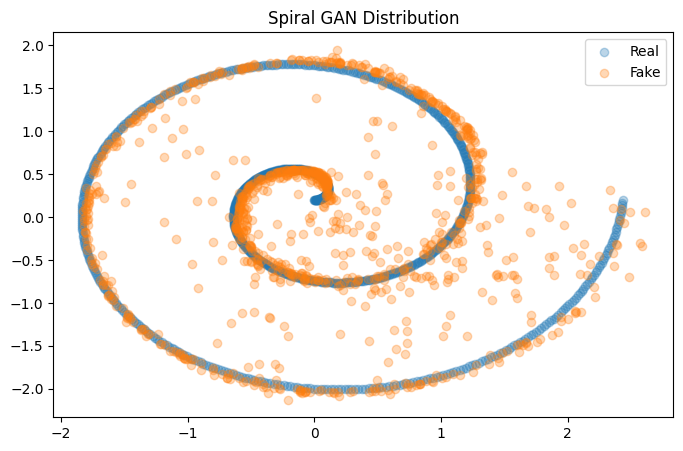

In [8]:
def generate_spiral(n=1000):
    theta = np.linspace(0, 4*np.pi, n)
    r = theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    data = np.stack([x, y], axis=1)
    data = (data - data.mean(0)) / data.std(0)
    return torch.tensor(data, dtype=torch.float32)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

# optimized training loop
def train_spiral_gan(data, epochs=6000, batch_size=256):
    G = Generator().to(device)
    D = Discriminator().to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    g_opt = optim.Adam(G.parameters(), lr=0.0002)
    d_opt = optim.Adam(D.parameters(), lr=0.0002)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    for epoch in range(epochs):
        idx = torch.randint(0, data.shape[0], (batch_size,))
        real = data[idx].to(device)

        for _ in range(2):
            z = torch.randn(batch_size, 2).to(device)
            fake = G(z).detach()
            d_opt.zero_grad()
            d_loss = loss_fn(D(real), real_labels) + loss_fn(D(fake), fake_labels)
            d_loss.backward()
            d_opt.step()

        z = torch.randn(batch_size, 2).to(device)
        fake = G(z)
        g_opt.zero_grad()
        g_loss = loss_fn(D(fake), real_labels)
        g_loss.backward()
        g_opt.step()

        if epoch % 1000 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    return G

spiral_data = generate_spiral()
G_spiral = train_spiral_gan(spiral_data)

with torch.no_grad():
    z = torch.randn(1000, 2).to(device)
    fake_spiral = G_spiral(z).cpu().numpy()

real_spiral = spiral_data.numpy()
plt.figure(figsize=(8, 5))
plt.scatter(real_spiral[:,0], real_spiral[:,1], alpha=0.3, label="Real")
plt.scatter(fake_spiral[:,0], fake_spiral[:,1], alpha=0.3, label="Fake")
plt.title("Spiral GAN Distribution")
plt.legend()
plt.show()

***Mixture of Gaussians***

Epoch 0 | D Loss: 1.3881 | G Loss: 0.7152
Epoch 1000 | D Loss: 1.1828 | G Loss: 1.1747
Epoch 2000 | D Loss: 1.3343 | G Loss: 0.9064
Epoch 3000 | D Loss: 1.3487 | G Loss: 0.7763
Epoch 4000 | D Loss: 1.3747 | G Loss: 0.7650
Epoch 5000 | D Loss: 1.3475 | G Loss: 0.8266


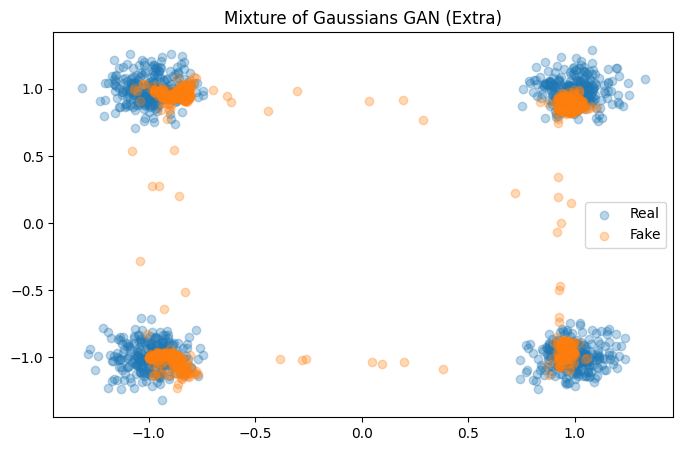

In [9]:
# generate a mixture of 4 gaussians
def generate_gaussians(n=1000):
    centers = [(-2,-2), (2,2), (-2,2), (2,-2)]
    data = []
    for cx, cy in centers:
        x = np.random.normal(cx, 0.2, n//4)
        y = np.random.normal(cy, 0.2, n//4)
        data.append(np.stack([x,y], axis=1))

    data = np.vstack(data)
    data = (data - data.mean(0)) / data.std(0)
    return torch.tensor(data, dtype=torch.float32)

# reused architectures (same as spiral)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

# training
def train_gaussians(data, epochs=6000, batch_size=256):
    G, D = Generator().to(device), Discriminator().to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    g_opt = optim.Adam(G.parameters(), lr=0.0002)
    d_opt = optim.Adam(D.parameters(), lr=0.0002)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    for epoch in range(epochs):
        idx = torch.randint(0, data.shape[0], (batch_size,))
        real = data[idx].to(device)

        # train D twice with fresh fakes
        for _ in range(2):
            z = torch.randn(batch_size, 2).to(device)
            fake = G(z).detach()
            d_opt.zero_grad()
            d_loss = loss_fn(D(real), real_labels) + loss_fn(D(fake), fake_labels)
            d_loss.backward()
            d_opt.step()

        # train G with fresh fake
        z = torch.randn(batch_size, 2).to(device)
        fake = G(z)
        g_opt.zero_grad()
        g_loss = loss_fn(D(fake), real_labels)
        g_loss.backward()
        g_opt.step()

        if epoch % 1000 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    return G

# execution and visualization
gaussian_data = generate_gaussians()
G_gauss = train_gaussians(gaussian_data)

# generate test samples safely
with torch.no_grad():
    z = torch.randn(1000, 2).to(device)
    fake_gauss = G_gauss(z).cpu().numpy()

plt.figure(figsize=(8, 5))
plt.scatter(gaussian_data[:,0], gaussian_data[:,1], alpha=0.3, label="Real")
plt.scatter(fake_gauss[:,0], fake_gauss[:,1], alpha=0.3, label="Fake")
plt.title("Mixture of Gaussians GAN (Extra)")
plt.legend()
plt.show()

***Noisy Parametric Curve***

Epoch 0 | D Loss: 1.3959 | G Loss: 0.7540
Epoch 1000 | D Loss: 1.3584 | G Loss: 0.7453
Epoch 2000 | D Loss: 1.3289 | G Loss: 0.7371
Epoch 3000 | D Loss: 1.3230 | G Loss: 0.7462
Epoch 4000 | D Loss: 1.3758 | G Loss: 0.7094
Epoch 5000 | D Loss: 1.3691 | G Loss: 0.7142


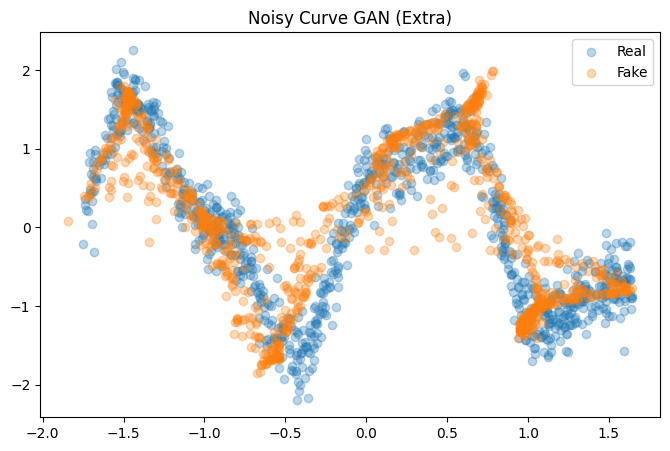

In [10]:
# generate normalized noisy parametric curve
def generate_curve(n=1000):
    x = np.random.uniform(-3, 3, n)
    noise = np.random.normal(0, 0.2, n)
    y = np.sin(2*x) + 0.3 * np.cos(5*x) + noise

    data = np.stack([x, y], axis=1)
    data = (data - data.mean(0)) / data.std(0)
    return torch.tensor(data, dtype=torch.float32)

# models (reusing the same architecture)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

# training
def train_curve(data, epochs=6000, batch_size=256):
    G, D = Generator().to(device), Discriminator().to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    g_opt = optim.Adam(G.parameters(), lr=0.0002)
    d_opt = optim.Adam(D.parameters(), lr=0.0002)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    for epoch in range(epochs):
        idx = torch.randint(0, data.shape[0], (batch_size,))
        real = data[idx].to(device)

        for _ in range(2):
            z = torch.randn(batch_size, 2).to(device)
            fake = G(z).detach()
            d_opt.zero_grad()
            d_loss = loss_fn(D(real), real_labels) + loss_fn(D(fake), fake_labels)
            d_loss.backward()
            d_opt.step()

        z = torch.randn(batch_size, 2).to(device)
        fake = G(z)
        g_opt.zero_grad()
        g_loss = loss_fn(D(fake), real_labels)
        g_loss.backward()
        g_opt.step()

        if epoch % 1000 == 0:
            print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    return G

# run and visualize
curve_data = generate_curve()
G_curve = train_curve(curve_data)

with torch.no_grad():
    z = torch.randn(1000, 2).to(device)
    fake_curve = G_curve(z).cpu().numpy()

real_curve = curve_data.numpy()

plt.figure(figsize=(8, 5))
plt.scatter(real_curve[:,0], real_curve[:,1], alpha=0.3, label="Real")
plt.scatter(fake_curve[:,0], fake_curve[:,1], alpha=0.3, label="Fake")
plt.title("Noisy Curve GAN (Extra)")
plt.legend()
plt.show()

### 1.3 Architecture Modification & Comparison
* **Original:** 2 hidden layers (32 neurons).
* **Modified:** 3 hidden layers (128 neurons) and removed output activation to match the unbounded Z-score normalization of the real data.

Training Original GAN (This may show partial mode collapse)...
Training Modified GAN (Deeper network, corrected activation)...


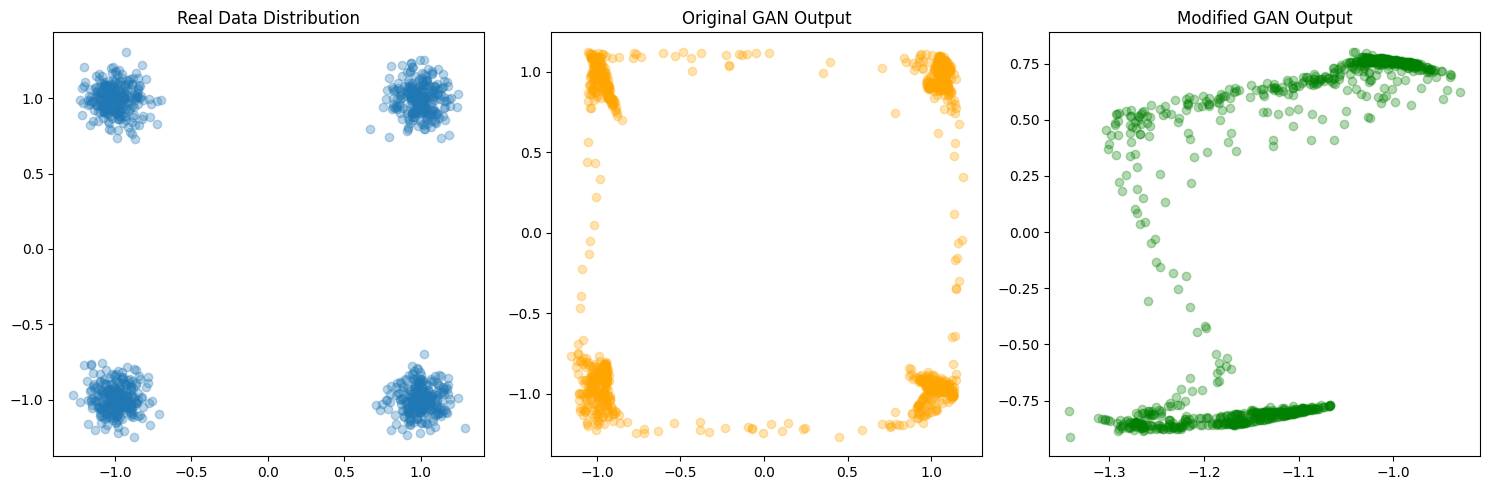

In [11]:
def generate_data(n=1000):
    centers = [(-2,-2), (2,2), (-2,2), (2,-2)]
    data = []
    for cx, cy in centers:
        x = np.random.normal(cx, 0.2, n//4)
        y = np.random.normal(cy, 0.2, n//4)
        data.append(np.stack([x,y], axis=1))

    data = np.vstack(data)
    data = (data - data.mean(0)) / data.std(0)
    return torch.tensor(data, dtype=torch.float32)

# Original Architecture
class Generator_Original(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, z): return self.net(z)

class Discriminator_Original(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

# Modified Architecture
class Generator_Modified(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, z): return self.net(z)

class Discriminator_Modified(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

# Training Function
def train_gan(G, D, data, epochs=5000, lr=0.0002, use_logits=False, batch_size=256):
    G, D = G.to(device), D.to(device)
    loss_fn = nn.BCEWithLogitsLoss() if use_logits else nn.BCELoss()

    g_opt = optim.Adam(G.parameters(), lr=lr)
    d_opt = optim.Adam(D.parameters(), lr=lr)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    for epoch in range(epochs):
        idx = torch.randint(0, data.shape[0], (batch_size,))
        real = data[idx].to(device)
        z = torch.randn(batch_size, 2).to(device)
        fake = G(z)

        # Train Discriminator
        for _ in range(2):
            d_opt.zero_grad()
            d_loss = loss_fn(D(real), real_labels) + loss_fn(D(fake.detach()), fake_labels)
            d_loss.backward()
            d_opt.step()

        # Train Generator
        g_opt.zero_grad()
        g_loss = loss_fn(D(fake), real_labels)
        g_loss.backward()
        g_opt.step()

    return G

# Visual Comparison
data = generate_data()

print("Training Original GAN (This may show partial mode collapse)...")
G_orig = train_gan(Generator_Original(), Discriminator_Original(), data, use_logits=False)

print("Training Modified GAN (Deeper network, corrected activation)...")
G_mod = train_gan(Generator_Modified(), Discriminator_Modified(), data, use_logits=True)

# Generate test samples
with torch.no_grad():
    z = torch.randn(1000, 2).to(device)
    fake_orig = G_orig(z).cpu().numpy()
    fake_mod = G_mod(z).cpu().numpy()

real_data = data.numpy()

# Plot comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(real_data[:,0], real_data[:,1], alpha=0.3)
plt.title("Real Data Distribution")

plt.subplot(1, 3, 2)
plt.scatter(fake_orig[:,0], fake_orig[:,1], alpha=0.3, color='orange')
plt.title("Original GAN Output")

plt.subplot(1, 3, 3)
plt.scatter(fake_mod[:,0], fake_mod[:,1], alpha=0.3, color='green')
plt.title("Modified GAN Output")

plt.tight_layout()
plt.show()

# Part 2: Real-World GAN Applications

### 2.1 Blood Cell Microscope Imaging with MedMNIST

Using downloaded and verified file: /home/photron/.medmnist/bloodmnist.npz
Total training images: 11959
------------------------------
Class Distribution:
0 (basophil): 852 images
1 (eosinophil): 2181 images
2 (erythroblast): 1085 images
3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)): 2026 images
4 (lymphocyte): 849 images
5 (monocyte): 993 images
6 (neutrophil): 2330 images
7 (platelet): 1643 images


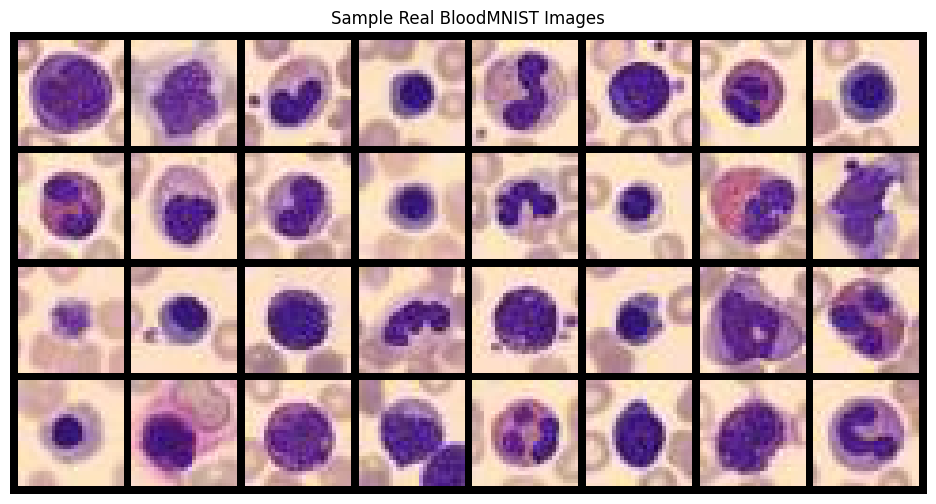

In [12]:
data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = DataClass(split='train', transform=transform, download=True)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# 1. Check Class Distribution
labels = np.array([label for _, label in train_dataset])
unique_classes, class_counts = np.unique(labels, return_counts=True)

print(f"Total training images: {len(train_dataset)}")
print("-" * 30)
print("Class Distribution:")
for class_idx, count in zip(unique_classes, class_counts):
    class_name = info['label'][str(class_idx)]
    print(f"{class_idx} ({class_name}): {count} images")

# 2. Visualize Sample Images
real_batch, _ = next(iter(train_loader))

plt.figure(figsize=(12, 6))
grid = make_grid(real_batch[:32], padding=2, normalize=True).cpu()
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.title("Sample Real BloodMNIST Images")
plt.axis('off')
plt.show()

***2.1.1 DCGAN Architecture***

In [13]:
class Generator_Blood(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator_Blood(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False)
            # no sigmoid — using BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

***2.1.2 BloodMNIST DCGAN Training***

In [14]:
G = Generator_Blood(z_dim=100).to(device)
D = Discriminator_Blood().to(device)

criterion = nn.BCEWithLogitsLoss()
g_opt = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_opt = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 50
z_dim  = 100
z_fixed_blood = torch.randn(16, z_dim, 1, 1, device=device)

g_losses, d_losses = [], []

print("Starting BloodMNIST GAN Training...")
start_time = time.time()

for epoch in range(epochs):
    G.train(); D.train()  # explicitly set train mode each epoch
    g_sum = d_sum = 0.0

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        batch_size = imgs.size(0)

        real_labels = torch.full((batch_size, 1), 0.9, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # train discriminator with fresh fake
        with torch.no_grad():
            fake_imgs = G(torch.randn(batch_size, z_dim, 1, 1, device=device))
        d_loss = criterion(D(imgs), real_labels) + criterion(D(fake_imgs), fake_labels)
        d_opt.zero_grad(set_to_none=True)
        d_loss.backward()
        d_opt.step()

        # train generator with fresh fake
        fake_imgs = G(torch.randn(batch_size, z_dim, 1, 1, device=device))
        g_loss = criterion(D(fake_imgs), real_labels)
        g_opt.zero_grad(set_to_none=True)
        g_loss.backward()
        g_opt.step()

        g_sum += g_loss.item()
        d_sum += d_loss.item()

    n = len(train_loader)
    g_losses.append(g_sum / n)
    d_losses.append(d_sum / n)
    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

print(f"Training complete in {(time.time() - start_time)/60:.2f} minutes.")

Starting BloodMNIST GAN Training...
Epoch 1/50 | D Loss: 0.4938 | G Loss: 2.8836
Epoch 2/50 | D Loss: 0.7391 | G Loss: 1.8251
Epoch 3/50 | D Loss: 0.8703 | G Loss: 1.6185
Epoch 4/50 | D Loss: 1.0497 | G Loss: 1.5063
Epoch 5/50 | D Loss: 1.0557 | G Loss: 1.4447
Epoch 6/50 | D Loss: 1.0015 | G Loss: 1.5369
Epoch 7/50 | D Loss: 0.8956 | G Loss: 1.7351
Epoch 8/50 | D Loss: 0.8448 | G Loss: 1.8241
Epoch 9/50 | D Loss: 0.8423 | G Loss: 1.8893
Epoch 10/50 | D Loss: 0.8079 | G Loss: 2.0191
Epoch 11/50 | D Loss: 0.7535 | G Loss: 1.9648
Epoch 12/50 | D Loss: 0.7363 | G Loss: 2.1472
Epoch 13/50 | D Loss: 0.6971 | G Loss: 2.2027
Epoch 14/50 | D Loss: 0.8552 | G Loss: 1.9578
Epoch 15/50 | D Loss: 0.6020 | G Loss: 2.3686
Epoch 16/50 | D Loss: 0.6264 | G Loss: 2.4886
Epoch 17/50 | D Loss: 0.8017 | G Loss: 2.0858
Epoch 18/50 | D Loss: 0.5845 | G Loss: 2.5704
Epoch 19/50 | D Loss: 0.6453 | G Loss: 2.5903
Epoch 20/50 | D Loss: 0.5069 | G Loss: 2.7817
Epoch 21/50 | D Loss: 0.6708 | G Loss: 2.3662
Epoch 2

***2.1.3 Visualization & Evaluation***

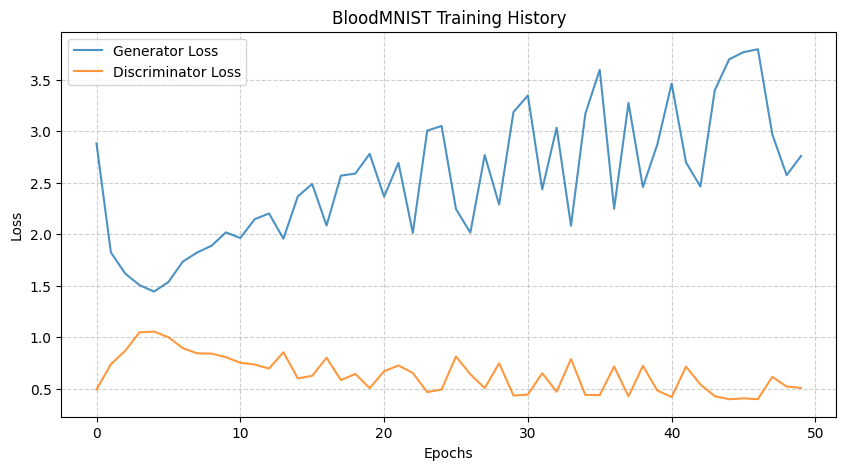

In [15]:
# Plot Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss", alpha=0.8)
plt.plot(d_losses, label="Discriminator Loss", alpha=0.8)
plt.title("BloodMNIST Training History")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("bloodmnist_loss_history.png")
plt.show()

***2.1.4 Comparison (Real vs Synthetic)***

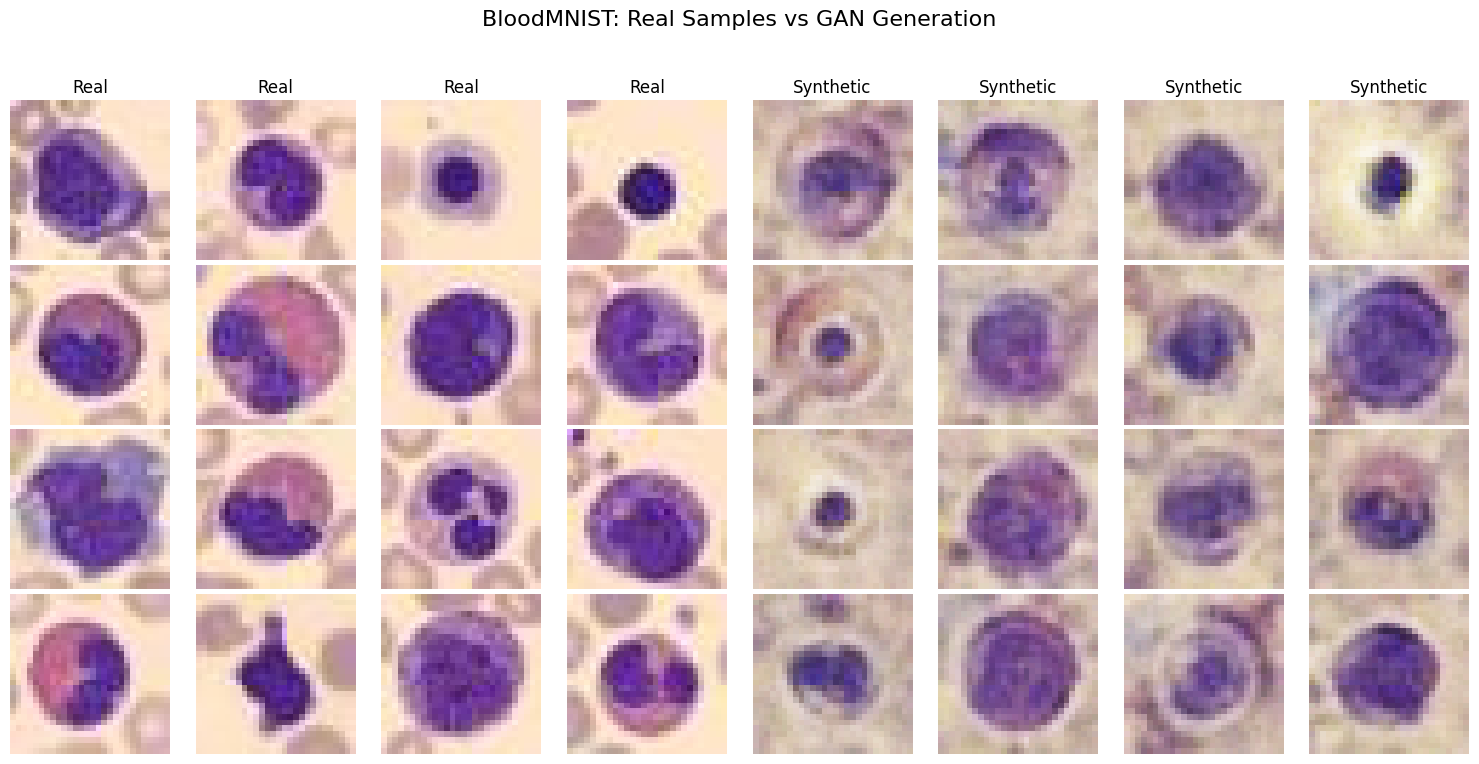

Generator_Blood(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

In [16]:
G.eval()
with torch.no_grad():
    fake_imgs = G(z_fixed_blood).cpu()  # use fixed noise for reproducibility
    real_imgs = next(iter(train_loader))[0][:16].cpu()

real_imgs = (real_imgs + 1) / 2
fake_imgs = (fake_imgs + 1) / 2

fig, axes = plt.subplots(4, 8, figsize=(15, 8))
for i in range(16):
    r, c = divmod(i, 4)
    axes[r, c].imshow(real_imgs[i].permute(1, 2, 0))
    axes[r, c].axis('off')
    if i < 4: axes[r, c].set_title("Real")

    axes[r, c+4].imshow(fake_imgs[i].permute(1, 2, 0))
    axes[r, c+4].axis('off')
    if i < 4: axes[r, c+4].set_title("Synthetic")

plt.suptitle("BloodMNIST: Real Samples vs GAN Generation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("bloodmnist_comparison.png")
plt.show()
G.train()

***2.1.5 Quantitative Evaluation: FID Score***

In [17]:
# Create temporary folders for FID calculation
os.makedirs("real_images", exist_ok=True)
os.makedirs("fake_images", exist_ok=True)

***i) Save 1,000 real images from the dataset***

In [18]:
count = 0
for imgs, _ in train_loader:
    imgs = (imgs + 1) / 2  # Denormalize to [0,1]
    for i in range(imgs.size(0)):
        save_image(imgs[i], f"real_images/{count}.png")
        count += 1
        if count >= 1000: break
    if count >= 1000: break
print(f"Saved {count} real images.")

Saved 1000 real images.


***ii) Save 1,000 fake images from the Generator***

In [19]:
G.eval()
with torch.no_grad():
    z = torch.randn(1000, z_dim, 1, 1).to(device)
    fake_imgs = G(z).cpu()
    fake_imgs = (fake_imgs + 1) / 2

for i in range(1000):
    save_image(fake_imgs[i], f"fake_images/{i}.png")
print("Saved 1,000 fake images.")
G.train()

Saved 1,000 fake images.


Generator_Blood(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

***iii) Calculate FID Score***

In [20]:
print("Calculating FID (this may take a moment)...")
bloodmnist_fid = calculate_fid_given_paths(
    ["real_images", "fake_images"],
    batch_size=50,
    device=device,
    dims=2048
)

print("-" * 30)
print(f"Final BloodMNIST FID Score: {bloodmnist_fid:.2f}")
print("-" * 30)

Calculating FID (this may take a moment)...


100%|███████████████████████████████████████████| 20/20 [00:05<00:00,  3.75it/s]


------------------------------
Final BloodMNIST FID Score: 228.43
------------------------------


***iv) Deleting temporary image folders***

In [21]:
shutil.rmtree("real_images")
shutil.rmtree("fake_images")
print("Temporary FID folders removed.")

Temporary FID folders removed.


---

### **2.2 Cybersecurity – Synthetic Traffic with CICIDS 2017**

In [22]:
import os
import pandas as pd
import pyarrow as pa
import pyarrow.csv as pv

folder = "data"
if not os.path.exists(folder): os.makedirs(folder)

# Load and merge all CSV files in the data folder
csv_files = [f for f in os.listdir(folder) if f.endswith('.csv')]
all_dfs = []

for f in csv_files:
    path = os.path.join(folder, f)
    print(f"Reading: {f}")
    try:
        df_temp = pd.read_csv(path, engine='pyarrow')
    except:
        df_temp = pd.read_csv(path, low_memory=False)
    all_dfs.append(df_temp)

if all_dfs:
    merged_df = pd.concat(all_dfs, ignore_index=True)
    # Clean column names and drop duplicates
    merged_df.columns = merged_df.columns.str.strip()
    merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

    # Save as a single merged file for the GAN
    table = pa.Table.from_pandas(merged_df)
    pv.write_csv(table, "merged_dataset.csv")
    print(f"Final merged shape: {merged_df.shape}")
else:
    print("No files found.")

Reading: Wednesday-workingHours.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: Monday-WorkingHours.pcap_ISCX.csv
Reading: Tuesday-WorkingHours.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Final merged shape: (2830743, 78)


***2.2.1 Preprocessing for Tabular GAN***


In [23]:
df = pd.read_csv("merged_dataset.csv", nrows=200000, low_memory=False)

df = df.select_dtypes(include=[np.number]).astype('float32')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(), inplace=True)
df = df.clip(lower=-1e6, upper=1e6)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)

# named separately so it doesn't overwrite the BloodMNIST train_loader
train_loader_cicids = DataLoader(TensorDataset(data_tensor), batch_size=1024, shuffle=True)

final_columns = df.columns
del df
gc.collect()

print(f"Data ready. Shape: {data_tensor.shape}")

Data ready. Shape: torch.Size([200000, 77])


***2.2.2 GAN Model for Tabular Data***

In [24]:
input_dim = data_tensor.shape[1]
z_dim_tab = 64

class Generator_Tab(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim_tab, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, input_dim)
        )
    def forward(self, z): return self.net(z)

class Discriminator_Tab(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

G_tab = Generator_Tab().to(device)
D_tab = Discriminator_Tab().to(device)
criterion_tab = nn.BCEWithLogitsLoss()
g_opt = optim.Adam(G_tab.parameters(), lr=0.0002)
d_opt = optim.Adam(D_tab.parameters(), lr=0.0002)

***2.2.3 GAN Training***

In [25]:
epochs = 50
g_losses_cicids, d_losses_cicids = [], []

for epoch in range(epochs):
    G_tab.train(); D_tab.train()
    g_sum = d_sum = 0.0

    for (real_data,) in train_loader_cicids:
        real_data = real_data.to(device, non_blocking=True)
        batch_sz  = real_data.size(0)

        real_labels = torch.full((batch_sz, 1), 0.9, device=device)
        fake_labels = torch.zeros(batch_sz, 1, device=device)

        # train D with fresh fake
        with torch.no_grad():
            fake_data = G_tab(torch.randn(batch_sz, z_dim_tab, device=device))
        d_loss = criterion_tab(D_tab(real_data), real_labels) + \
                 criterion_tab(D_tab(fake_data), fake_labels)
        d_opt.zero_grad(set_to_none=True); d_loss.backward(); d_opt.step()

        # train G with fresh fake
        fake_data = G_tab(torch.randn(batch_sz, z_dim_tab, device=device))
        g_loss = criterion_tab(D_tab(fake_data), real_labels)
        g_opt.zero_grad(set_to_none=True); g_loss.backward(); g_opt.step()

        g_sum += g_loss.item(); d_sum += d_loss.item()

    n = len(train_loader_cicids)
    g_losses_cicids.append(g_sum / n)
    d_losses_cicids.append(d_sum / n)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} | D Loss: {d_losses_cicids[-1]:.4f} | G Loss: {g_losses_cicids[-1]:.4f}")

Epoch 10 | D Loss: 0.6023 | G Loss: 2.3101
Epoch 20 | D Loss: 0.6273 | G Loss: 2.5830
Epoch 30 | D Loss: 0.6310 | G Loss: 2.6026
Epoch 40 | D Loss: 0.6540 | G Loss: 2.3549
Epoch 50 | D Loss: 0.6320 | G Loss: 2.3955


***2.2.4 Evaluation: Visuals and Statistical Mean Comparison***

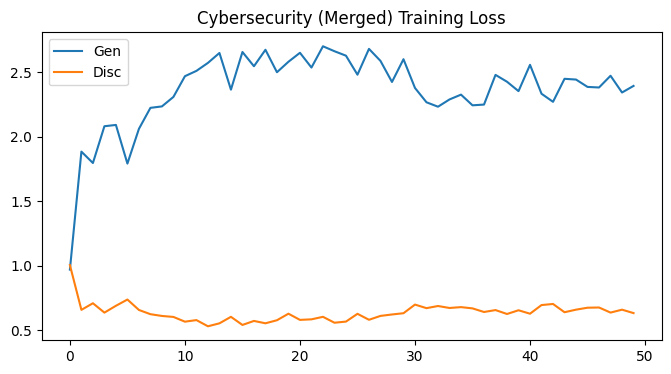


--- Merged Mean Comparison (Top 5) ---
                                 Real Mean  Synthetic Mean
Destination Port               5762.004883      434.819885
Flow Duration                594862.250000   979234.812500
Total Fwd Packets               406.941010        6.575058
Total Backward Packets          516.098022       24.249935
Total Length of Fwd Packets    5061.094238      669.112610


Generator_Tab(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=77, bias=True)
  )
)

In [26]:
# Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(g_losses_cicids, label="Gen")
plt.plot(d_losses_cicids, label="Disc")
plt.title("Cybersecurity (Merged) Training Loss")
plt.legend(); plt.show()

G_tab.eval()
z = torch.randn(1000, z_dim_tab, device=device)
with torch.no_grad():
    syn_data = scaler.inverse_transform(G_tab(z).cpu().numpy())
synthetic_df   = pd.DataFrame(syn_data, columns=final_columns)
real_df_sample = pd.DataFrame(scaler.inverse_transform(data_tensor[:1000].numpy()), columns=final_columns)

print("\n--- Merged Mean Comparison (Top 5) ---")
print(pd.DataFrame({'Real Mean': real_df_sample.mean().head(), 'Synthetic Mean': synthetic_df.mean().head()}))
G_tab.train()

***2.2.5 GAN on Wednesday Data (Benign vs DoS)***

###### i) Loading

In [27]:
df_wed = pd.read_csv("data/Wednesday-workingHours.pcap_ISCX.csv", low_memory=False)
df_wed.columns = df_wed.columns.str.strip()

# Filtering for only Benign and DoS traffic
df_wed = df_wed[df_wed['Label'].isin(['BENIGN', 'DoS'])]

print("Filtered shape:", df_wed.shape)
print(df_wed['Label'].value_counts())

Filtered shape: (440031, 79)
Label
BENIGN    440031
Name: count, dtype: int64


###### ii) Preprocessing

In [28]:
# Keeping numeric features and fixing values
df_wed_num = df_wed.drop(columns=['Label']).select_dtypes(include=['float64', 'int64'])

df_wed_num.replace([np.inf, -np.inf], np.nan, inplace=True)
df_wed_num.fillna(df_wed_num.median(), inplace=True)
df_wed_num = df_wed_num.clip(-1e6, 1e6)

# Scaling and making the tensor
scaler_wed = StandardScaler()
data_scaled_wed = scaler_wed.fit_transform(df_wed_num)
data_tensor_wed = torch.tensor(data_scaled_wed, dtype=torch.float32)

# Loader with larger batch size to speed things up
train_loader_wed = DataLoader(TensorDataset(data_tensor_wed), batch_size=1024, shuffle=True)

print("Preprocessing done. Shape:", data_tensor_wed.shape)

Preprocessing done. Shape: torch.Size([440031, 78])


###### iii) EDA

/tmp/ipykernel_44329/1050329015.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_wed_num[col].dropna() for col in top_features],


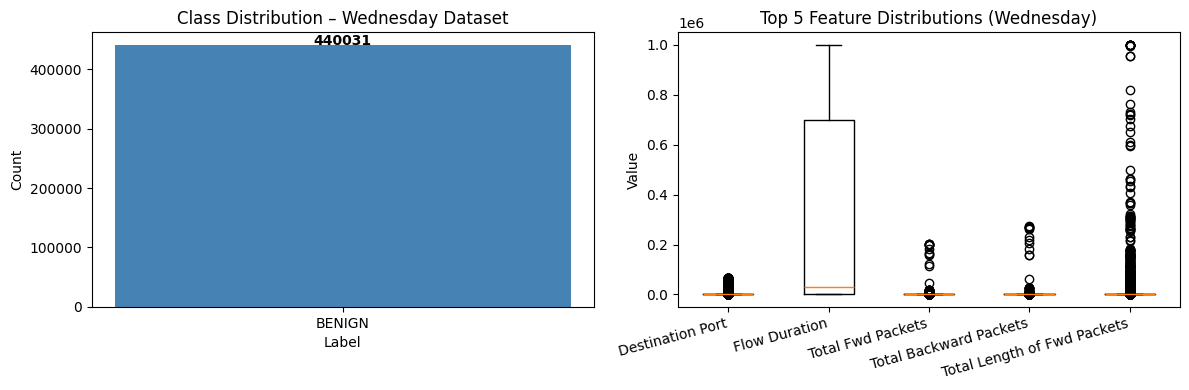


--- Feature Summary (Wednesday) ---
       Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean  Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean  Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CWE Flag Count  ECE Flag Count  Down/Up Ratio  Average Packet Size  Avg Fwd Segment Size

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class balance bar chart
class_counts = df_wed['Label'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title("Class Distribution – Wednesday Dataset")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# top 5 feature distributions
top_features = df_wed_num.columns[:5]
axes[1].boxplot([df_wed_num[col].dropna() for col in top_features],
                labels=top_features, vert=True)
axes[1].set_title("Top 5 Feature Distributions (Wednesday)")
axes[1].set_xticklabels(top_features, rotation=15, ha='right')
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.savefig("wednesday_eda.png", dpi=150)
plt.show()

# print basic stats
print("\n--- Feature Summary (Wednesday) ---")
print(df_wed_num.describe().round(2).to_string())

###### iv) Training

In [30]:
input_dim = data_tensor_wed.shape[1]  # recalculate for wednesday features

G_wed = Generator_Tab().to(device)
D_wed = Discriminator_Tab().to(device)

criterion_wed = nn.BCEWithLogitsLoss()
g_opt_wed = optim.Adam(G_wed.parameters(), lr=0.0002)
d_opt_wed = optim.Adam(D_wed.parameters(), lr=0.0002)

epochs = 50
g_losses_wed, d_losses_wed = [], []

for epoch in range(epochs):
    G_wed.train(); D_wed.train()
    g_sum = d_sum = 0.0

    for (real_data,) in train_loader_wed:
        real_data = real_data.to(device, non_blocking=True)
        batch_sz  = real_data.size(0)

        real_labels = torch.full((batch_sz, 1), 0.9, device=device)
        fake_labels = torch.zeros(batch_sz, 1, device=device)

        # train D with fresh fake
        with torch.no_grad():
            fake_data = G_wed(torch.randn(batch_sz, z_dim_tab, device=device))
        d_loss = criterion_wed(D_wed(real_data), real_labels) + \
                 criterion_wed(D_wed(fake_data), fake_labels)
        d_opt_wed.zero_grad(set_to_none=True); d_loss.backward(); d_opt_wed.step()

        # train G with fresh fake
        fake_data = G_wed(torch.randn(batch_sz, z_dim_tab, device=device))
        g_loss = criterion_wed(D_wed(fake_data), real_labels)
        g_opt_wed.zero_grad(set_to_none=True); g_loss.backward(); g_opt_wed.step()

        g_sum += g_loss.item(); d_sum += d_loss.item()

    n = len(train_loader_wed)
    g_losses_wed.append(g_sum / n)
    d_losses_wed.append(d_sum / n)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | D Loss: {d_losses_wed[-1]:.4f} | G Loss: {g_losses_wed[-1]:.4f}")

Epoch 10/50 | D Loss: 0.5902 | G Loss: 2.5509
Epoch 20/50 | D Loss: 0.6517 | G Loss: 2.4511
Epoch 30/50 | D Loss: 0.7168 | G Loss: 2.2264
Epoch 40/50 | D Loss: 0.8132 | G Loss: 1.8495
Epoch 50/50 | D Loss: 0.8721 | G Loss: 1.6556


###### v) Visualization and Statistics

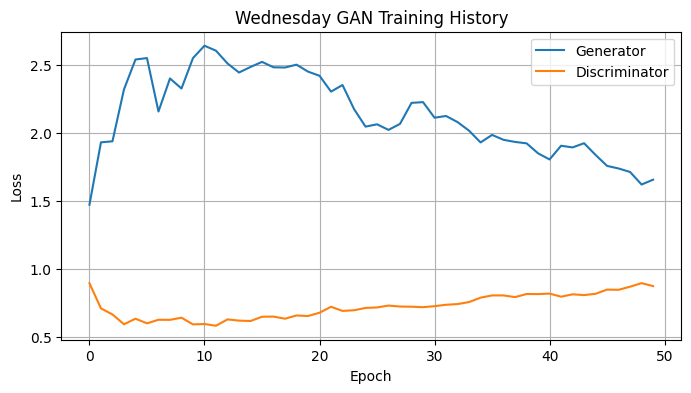

In [31]:
# 1. Training Loss History
plt.figure(figsize=(8, 4))
plt.plot(g_losses_wed, label="Generator")
plt.plot(d_losses_wed, label="Discriminator")
plt.title("Wednesday GAN Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# 2. Generate Synthetic Data
G_wed.eval()
z = torch.randn(1000, z_dim_tab).to(device)
with torch.no_grad():
    syn_scaled = G_wed(z).cpu().numpy()
synthetic_df_wed = pd.DataFrame(scaler_wed.inverse_transform(syn_scaled), columns=df_wed_num.columns)

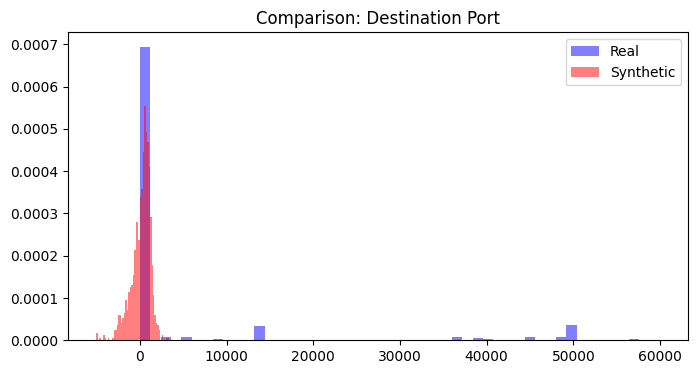

In [34]:
# 3. Visual Comparison: Histogram of first feature
plt.figure(figsize=(8, 4))
plt.hist(df_wed_num.iloc[:1000, 0], bins=50, alpha=0.5, label="Real", color='blue', density=True)
plt.hist(synthetic_df_wed.iloc[:, 0], bins=50, alpha=0.5, label="Synthetic", color='red', density=True)
plt.title(f"Comparison: {df_wed_num.columns[0]}")
plt.legend()
plt.show()

In [35]:
# 4. Statistical Mean Comparison
print("\n--- Wednesday Mean Comparison (First 5) ---")
comp = pd.DataFrame({
    'Real Mean': df_wed_num.mean().head(),
    'Synthetic Mean': synthetic_df_wed.mean().head()
})
print(comp)


--- Wednesday Mean Comparison (First 5) ---
                                 Real Mean  Synthetic Mean
Destination Port               8906.403806      158.262421
Flow Duration                282815.302486    66614.695312
Total Fwd Packets                11.913174      -27.509890
Total Backward Packets           13.702460       -5.472315
Total Length of Fwd Packets     696.355418      -50.502678


***2.2.6 Using t-SNE to visualise and compare real vs. generated feature vectors***

###### i) Preparing data for Dimensionality Reduction

In [37]:
# get real data sample
real_sample = data_tensor_wed[:1000].cpu().numpy()

# generate fake data sample
G_wed.eval()
with torch.no_grad():
    z = torch.randn(1000, z_dim_tab).to(device)
    fake_sample = G_wed(z).cpu().numpy()
G_wed.train()

# stack them together and create labels (0 for real, 1 for fake)
combined_data = np.vstack((real_sample, fake_sample))
plot_labels = np.array([0]*1000 + [1]*1000)

print("Data ready for t-SNE. Combined shape:", combined_data.shape)

Data ready for t-SNE. Combined shape: (2000, 78)


###### ii) t-SNE plotting

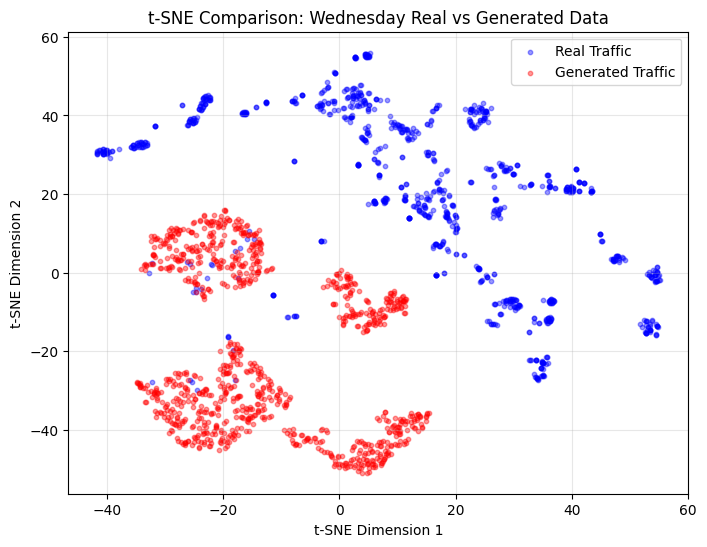

t-SNE plot saved as: cybersecurity_tsne_comparison.png


In [38]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(combined_data)

# plotting the results
plt.figure(figsize=(8, 6))

# plot real points in blue
plt.scatter(tsne_result[plot_labels==0, 0], tsne_result[plot_labels==0, 1],
            alpha=0.4, label='Real Traffic', c='blue', s=10)

# plot fake points in red
plt.scatter(tsne_result[plot_labels==1, 0], tsne_result[plot_labels==1, 1],
            alpha=0.4, label='Generated Traffic', c='red', s=10)

plt.legend()
plt.title("t-SNE Comparison: Wednesday Real vs Generated Data")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)
plt.savefig("cybersecurity_tsne_comparison.png", dpi=150)
plt.show()

print("t-SNE plot saved as: cybersecurity_tsne_comparison.png")

###### iii) PCA plotting

PCA explained variance: 87.2% in 2 components


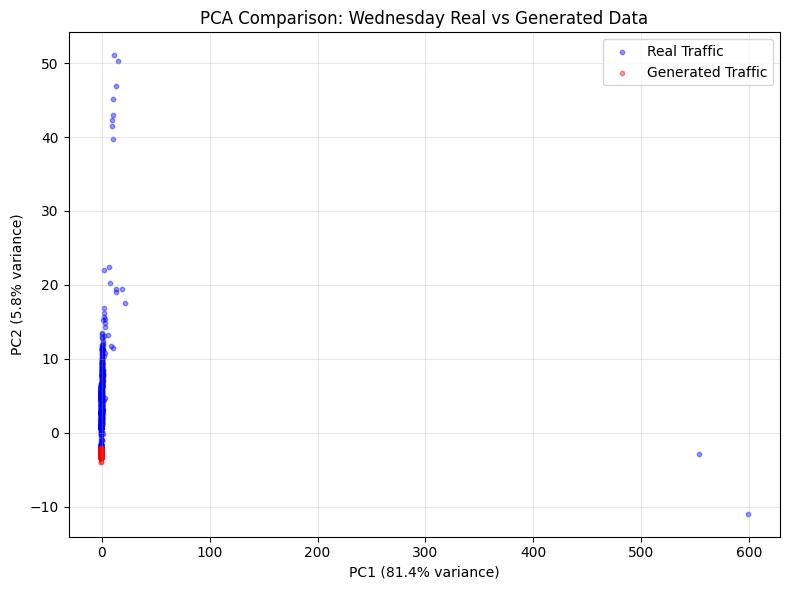

PCA plot saved.


In [42]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(combined_data)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% in 2 components")

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[plot_labels==0, 0], pca_result[plot_labels==0, 1],
            alpha=0.4, label='Real Traffic', c='blue', s=10)
plt.scatter(pca_result[plot_labels==1, 0], pca_result[plot_labels==1, 1],
            alpha=0.4, label='Generated Traffic', c='red', s=10)
plt.legend()
plt.title("PCA Comparison: Wednesday Real vs Generated Data")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cybersecurity_pca_comparison.png", dpi=150)
plt.show()
print("PCA plot saved.")

***2.2.7 Loading full merged data***

In [43]:
full_df = pd.read_csv("merged_dataset.csv", nrows=500000, low_memory=False)

full_df_num = full_df.select_dtypes(include=[np.number]).astype('float32')
full_df_num.replace([np.inf, -np.inf], np.nan, inplace=True)
full_df_num.fillna(full_df_num.median(), inplace=True)

scaler_full = StandardScaler()
data_scaled_full = scaler_full.fit_transform(full_df_num)
data_tensor_full = torch.tensor(data_scaled_full, dtype=torch.float32)

train_loader_full = DataLoader(TensorDataset(data_tensor_full), batch_size=512, shuffle=True)

print(f"Data Loaded. Features: {data_tensor_full.shape[1]}")

Data Loaded. Features: 77


***2.2.8 Training on Full CICIDS Dataset (All Days)***

In [47]:
input_dim_full = data_tensor_full.shape[1]

class Generator_Full(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim_tab, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, input_dim_full)
        )
    def forward(self, z): return self.net(z)

class Discriminator_Full(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim_full, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

G_full = Generator_Full().to(device)
D_full = Discriminator_Full().to(device)
g_opt_full = optim.Adam(G_full.parameters(), lr=0.0002)
d_opt_full = optim.Adam(D_full.parameters(), lr=0.0002)
criterion_full = nn.BCEWithLogitsLoss()

g_losses_full, d_losses_full = [], []

for epoch in range(50):
    G_full.train(); D_full.train()
    g_sum = d_sum = 0.0
    for (real_data,) in train_loader_full:
        real_data = real_data.to(device, non_blocking=True)
        bs = real_data.size(0)
        rl = torch.full((bs, 1), 0.9, device=device)
        fl = torch.zeros(bs, 1, device=device)

        with torch.no_grad():
            fake = G_full(torch.randn(bs, z_dim_tab, device=device))
        d_loss = criterion_full(D_full(real_data), rl) + criterion_full(D_full(fake), fl)
        d_opt_full.zero_grad(set_to_none=True); d_loss.backward(); d_opt_full.step()

        fake = G_full(torch.randn(bs, z_dim_tab, device=device))
        g_loss = criterion_full(D_full(fake), rl)
        g_opt_full.zero_grad(set_to_none=True); g_loss.backward(); g_opt_full.step()

        g_sum += g_loss.item(); d_sum += d_loss.item()

    g_losses_full.append(g_sum / len(train_loader_full))
    d_losses_full.append(d_sum / len(train_loader_full))
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | D: {d_losses_full[-1]:.4f} | G: {g_losses_full[-1]:.4f}")

Epoch 10/50 | D: 0.5872 | G: 3.0702
Epoch 20/50 | D: 0.7601 | G: 2.1455
Epoch 30/50 | D: 0.8241 | G: 1.9095
Epoch 40/50 | D: 0.8642 | G: 1.7804
Epoch 50/50 | D: 0.8863 | G: 1.7205


***2.2.9 Final Comparison of the 3 Models***

In [48]:
torch.save(G.state_dict(),       "G_pizza.pt")
torch.save(G_wed.state_dict(),   "G_wed.pt")
torch.save(G_full.state_dict(),  "G_full.pt")

summary_report = pd.DataFrame({
    "Dataset":        ["BloodMNIST", "Wednesday (DoS)", "Full Merged (Extra Credit)"],
    "GAN Type":       ["DCGAN (Image)", "MLP (Tabular)", "MLP (Tabular)"],
    "Status":         ["Completed", "Completed", "Completed"],
    "Primary Metric": ["FID Score", "Mean/t-SNE Comparison", "Generalization Analysis"],
    "Final G Loss":   [round(g_losses[-1], 4), round(g_losses_wed[-1], 4), round(g_losses_full[-1], 4)],
    "Final D Loss":   [round(d_losses[-1], 4), round(d_losses_wed[-1], 4), round(d_losses_full[-1], 4)],
})

display(summary_report)

,Dataset,GAN Type,Status,Primary Metric,Final G Loss,Final D Loss
0,BloodMNIST,DCGAN (Image),Completed,FID Score,2.7616,0.5095
1,Wednesday (DoS),MLP (Tabular),Completed,Mean/t-SNE Comparison,1.6556,0.8721
2,Full Merged (Extra Credit),MLP (Tabular),Completed,Generalization Analysis,1.7205,0.8863


### **2.3 Creative AI – QuickDraw 'Pizza' Subset**

In [49]:
# Dataset Download
os.makedirs("data", exist_ok=True)

url = "https://storage.googleapis.com/quickdraw_dataset/full/raw/pizza.ndjson"
if not os.path.exists("data/pizza.ndjson"):
    print("Downloading pizza dataset...")
    urllib.request.urlretrieve(url, "data/pizza.ndjson")
    print("Done.")
else:
    print("Already downloaded.")

Already downloaded.


In [50]:
pizza_drawings = []

with open("data/pizza.ndjson", "r") as f:
    for line in f:
        sample = json.loads(line)
        if sample.get("recognized"):
            pizza_drawings.append(sample["drawing"])
        if len(pizza_drawings) >= 5000:
            break

print(f"Loaded {len(pizza_drawings)} pizza sketches")

Loaded 5000 pizza sketches


***2.3.1 Preparing the Dataset***

Image shape: (32, 32), range: [0, 0]


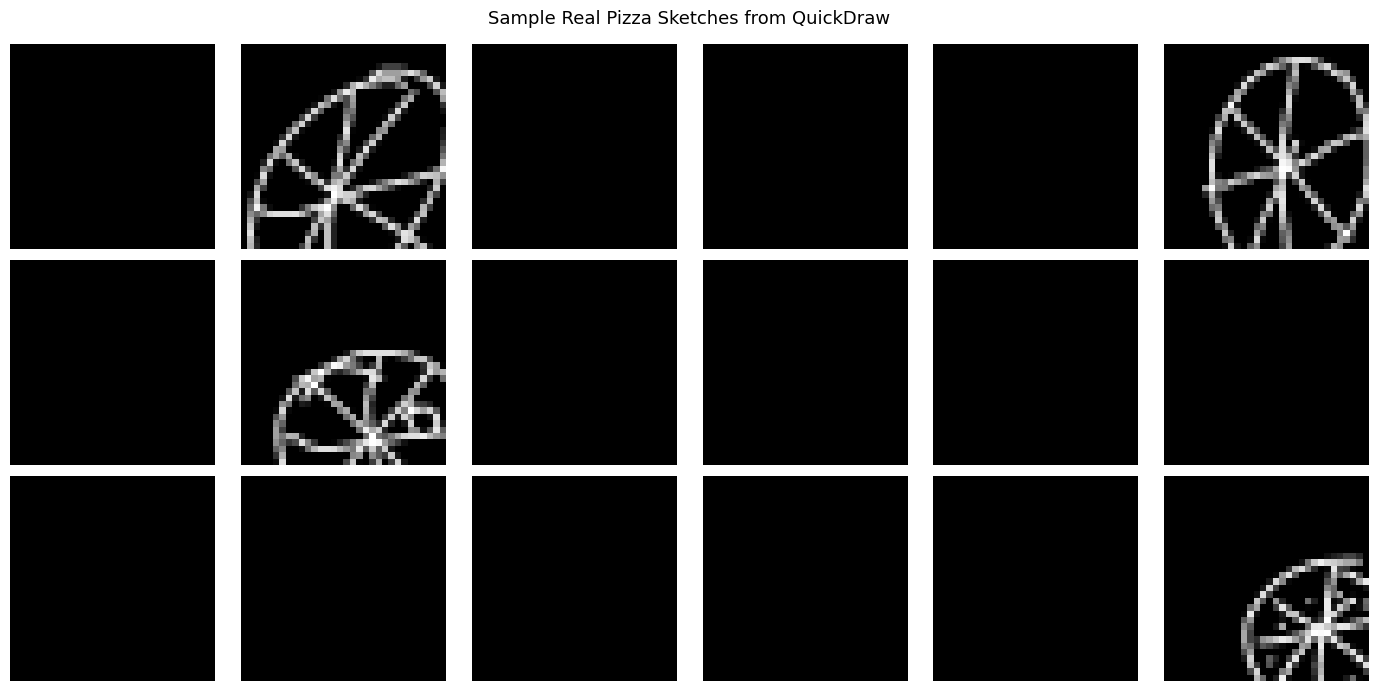

In [51]:
def draw_to_image(drawing, size=32):
    # create blank canvas and draw each stroke
    img = np.zeros((256, 256), dtype=np.uint8)
    for stroke in drawing:
        x, y = stroke[0], stroke[1]
        for i in range(len(x) - 1):
            cv2.line(img, (int(x[i]), int(y[i])), (int(x[i+1]), int(y[i+1])), 255, 5)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img

test_img = draw_to_image(pizza_drawings[0])
print(f"Image shape: {test_img.shape}, range: [{test_img.min()}, {test_img.max()}]")

# Real samples visualization
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    img = draw_to_image(pizza_drawings[i])
    ax.imshow(img, cmap="gray")
    ax.axis("off")
fig.suptitle("Sample Real Pizza Sketches from QuickDraw", fontsize=13)
plt.tight_layout()
plt.savefig("pizza_samples.png", dpi=150)
plt.show()

***2.3.2 Data Preprocessing***

In [52]:
processed = []
for drawing in pizza_drawings:
    img = draw_to_image(drawing)
    if img.max() > 0:
        img = (img.astype(np.float32) / 127.5) - 1.0  # normalise to [-1, 1]
        processed.append(img)

print(f"Valid sketches after filtering blanks: {len(processed)}")

pizza_tensor = torch.tensor(np.array(processed)).unsqueeze(1)
print(f"Tensor shape: {pizza_tensor.shape}, range: [{pizza_tensor.min():.3f}, {pizza_tensor.max():.3f}]")

dataset_pizza    = TensorDataset(pizza_tensor)
train_loader_pizza = DataLoader(
    dataset_pizza,
    batch_size=64,
    shuffle=True,
    num_workers=min(4, os.cpu_count()),
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

sample, = next(iter(train_loader_pizza))
print(f"Pizza loader check — shape: {sample.shape}, range: [{sample.min():.3f}, {sample.max():.3f}]")

Valid sketches after filtering blanks: 1206
Tensor shape: torch.Size([1206, 1, 32, 32]), range: [-1.000, 1.000]
Pizza loader check — shape: torch.Size([64, 1, 32, 32]), range: [-1.000, 1.000]


***2.3.3 EDA for QuickDraw***

Total sketches loaded: 5000


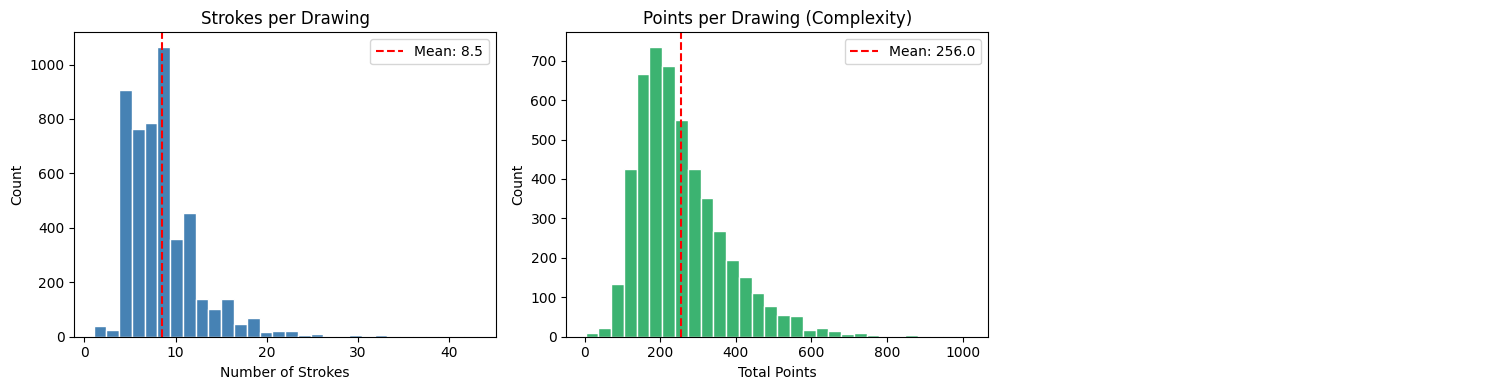

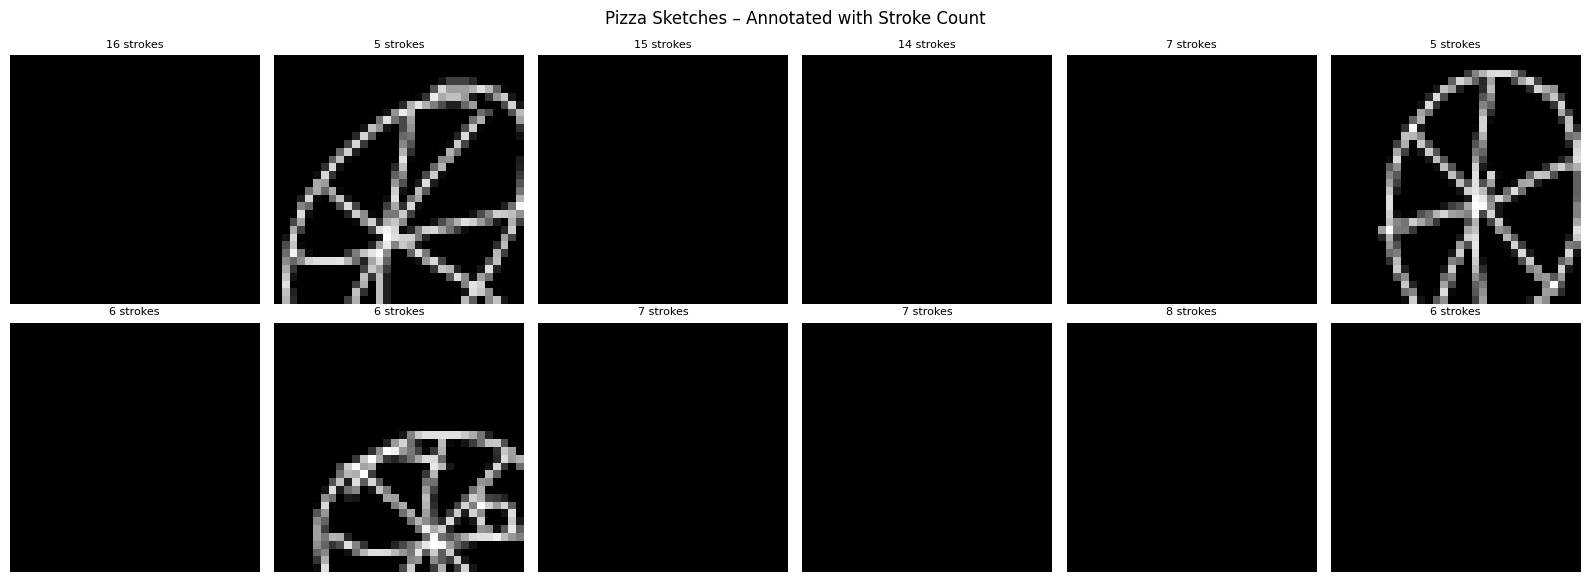


Stroke count  — min: 1, max: 43, mean: 8.5
Point count   — min: 3,  max: 1016,  mean: 256.0


In [53]:
print(f"Total sketches loaded: {len(pizza_drawings)}")

# stroke count per drawing
stroke_counts = [len(d) for d in pizza_drawings]
# total points per drawing (complexity)
point_counts  = [sum(len(s[0]) for s in d) for d in pizza_drawings]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# stroke count distribution
axes[0].hist(stroke_counts, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Strokes per Drawing")
axes[0].set_xlabel("Number of Strokes")
axes[0].set_ylabel("Count")
axes[0].axvline(np.mean(stroke_counts), color='red', linestyle='--',
                label=f"Mean: {np.mean(stroke_counts):.1f}")
axes[0].legend()

# point count distribution (drawing complexity)
axes[1].hist(point_counts, bins=30, color='mediumseagreen', edgecolor='white')
axes[1].set_title("Points per Drawing (Complexity)")
axes[1].set_xlabel("Total Points")
axes[1].set_ylabel("Count")
axes[1].axvline(np.mean(point_counts), color='red', linestyle='--',
                label=f"Mean: {np.mean(point_counts):.1f}")
axes[1].legend()

# sample 6 sketches with stroke count annotated
axes[2].axis('off')
fig2, axes2 = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes2.flatten()):
    img = draw_to_image(pizza_drawings[i])
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{len(pizza_drawings[i])} strokes", fontsize=8)
    ax.axis('off')
fig2.suptitle("Pizza Sketches – Annotated with Stroke Count", fontsize=12)
plt.tight_layout()
plt.savefig("pizza_eda_samples.png", dpi=150)

fig.tight_layout()
plt.savefig("pizza_eda_stats.png", dpi=150)
plt.show()

print(f"\nStroke count  — min: {min(stroke_counts)}, max: {max(stroke_counts)}, mean: {np.mean(stroke_counts):.1f}")
print(f"Point count   — min: {min(point_counts)},  max: {max(point_counts)},  mean: {np.mean(point_counts):.1f}")

***2.3.4 ConvNet-based GAN (DCGAN) to model the sketches***

In [54]:
z_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 128, 4, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.zeros_(m.bias)

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight, 1.0, 0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).view(-1, 1)

G = Generator().to(device)
D = Discriminator().to(device)
print(G)
print(D)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), str

***2.3.5 Training the GAN***

In [55]:
criterion = nn.BCELoss()
g_opt = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_opt = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs  = 50
z_fixed = torch.randn(16, z_dim, 1, 1, device=device)

g_losses, d_losses = [], []
snapshot_epochs = [1, 10, 20, 30, 40, 50]  # epochs to save visual snapshots
snapshots = {}                               # store grids for final comparison plot

for epoch in range(epochs):
    G.train(); D.train()
    g_sum = d_sum = 0.0

    for (real_imgs,) in train_loader_pizza:
        real_imgs  = real_imgs.to(device, non_blocking=True)
        batch_size = real_imgs.size(0)

        real_labels = torch.full((batch_size, 1), 0.9, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # train discriminator
        with torch.no_grad():
            fake_imgs = G(torch.randn(batch_size, z_dim, 1, 1, device=device))
        d_loss = criterion(D(real_imgs), real_labels) + criterion(D(fake_imgs), fake_labels)
        d_opt.zero_grad(set_to_none=True)
        d_loss.backward()
        d_opt.step()

        # train generator
        fake_imgs = G(torch.randn(batch_size, z_dim, 1, 1, device=device))
        g_loss = criterion(D(fake_imgs), real_labels)
        g_opt.zero_grad(set_to_none=True)
        g_loss.backward()
        g_opt.step()

        g_sum += g_loss.item()
        d_sum += d_loss.item()

    n = len(train_loader_pizza)
    g_losses.append(g_sum / n)
    d_losses.append(d_sum / n)
    print(f"Epoch [{epoch+1:>2}/{epochs}] | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")

    # save visual snapshot at key epochs
    if (epoch + 1) in snapshot_epochs:
        G.eval()
        with torch.no_grad():
            snap = ((G(z_fixed).cpu() + 1) / 2).clamp(0, 1)
        snapshots[epoch + 1] = snap

        fig, axes = plt.subplots(2, 8, figsize=(14, 4))
        for i, ax in enumerate(axes.flatten()):
            ax.imshow(snap[i % 16].squeeze(), cmap='gray')
            ax.axis('off')
        fig.suptitle(f"Generated Pizza Sketches – Epoch {epoch+1}", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"pizza_epoch_{epoch+1:02d}.png", dpi=150)
        plt.close()
        G.train()

pizza_final_g_loss = g_losses[-1]
pizza_final_d_loss = d_losses[-1]
print("Training complete. Snapshots saved.")

Epoch [ 1/50] | D Loss: 0.5452 | G Loss: 3.5150
Epoch [ 2/50] | D Loss: 0.6255 | G Loss: 4.2443
Epoch [ 3/50] | D Loss: 0.5151 | G Loss: 4.0136
Epoch [ 4/50] | D Loss: 0.6254 | G Loss: 4.5976
Epoch [ 5/50] | D Loss: 0.4853 | G Loss: 3.8320
Epoch [ 6/50] | D Loss: 0.4160 | G Loss: 3.9154
Epoch [ 7/50] | D Loss: 0.3861 | G Loss: 4.1475
Epoch [ 8/50] | D Loss: 0.3748 | G Loss: 4.2887
Epoch [ 9/50] | D Loss: 0.3655 | G Loss: 4.3334
Epoch [10/50] | D Loss: 0.6349 | G Loss: 4.9758
Epoch [11/50] | D Loss: 0.5122 | G Loss: 4.3072
Epoch [12/50] | D Loss: 0.3923 | G Loss: 4.3399
Epoch [13/50] | D Loss: 0.3787 | G Loss: 4.1305
Epoch [14/50] | D Loss: 0.3640 | G Loss: 4.5021
Epoch [15/50] | D Loss: 0.3628 | G Loss: 4.3304
Epoch [16/50] | D Loss: 0.3938 | G Loss: 4.4752
Epoch [17/50] | D Loss: 0.5785 | G Loss: 5.3128
Epoch [18/50] | D Loss: 0.4505 | G Loss: 4.7945
Epoch [19/50] | D Loss: 0.3933 | G Loss: 4.4942
Epoch [20/50] | D Loss: 0.3739 | G Loss: 4.3409
Epoch [21/50] | D Loss: 0.3795 | G Loss:

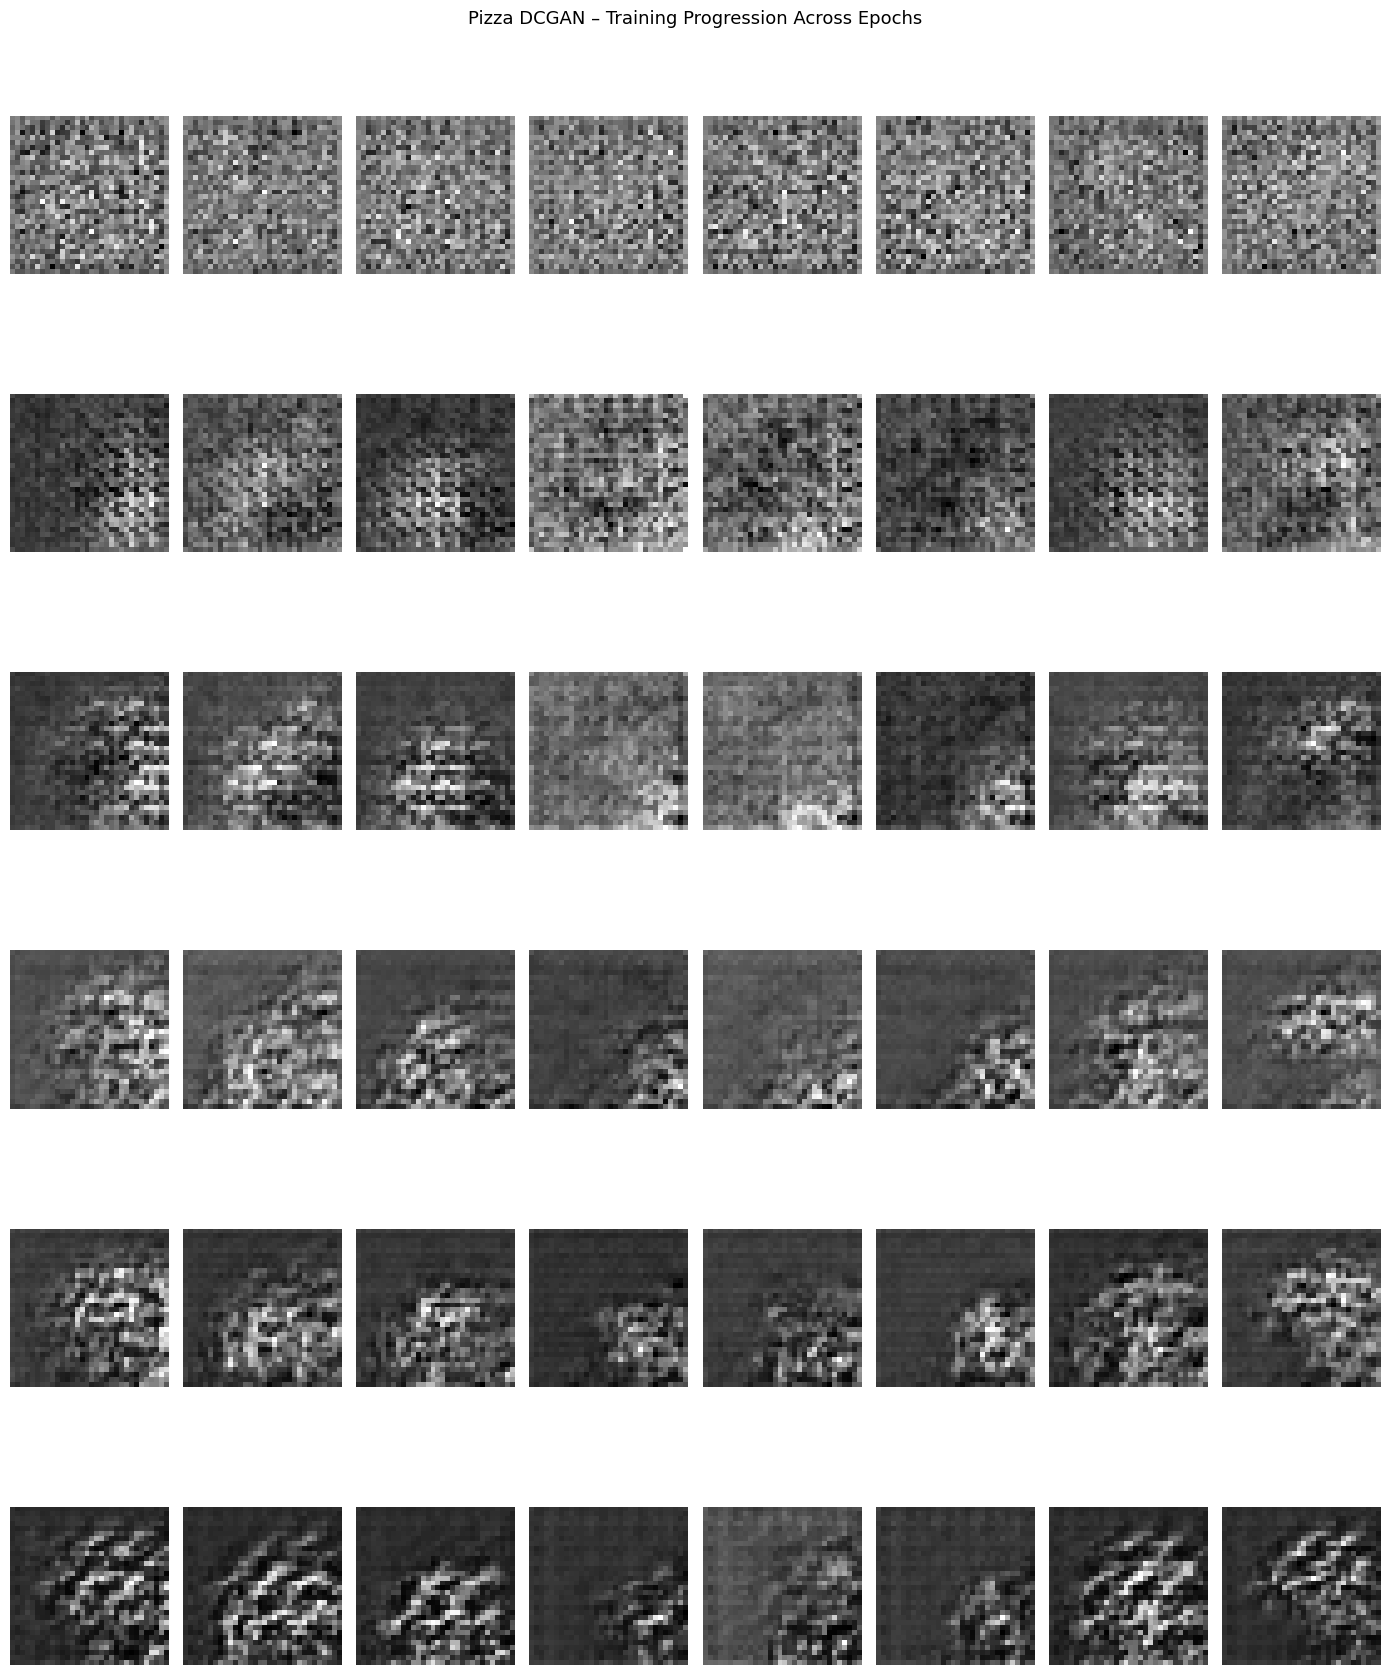

Saved: pizza_training_progression.png


In [56]:
# show all snapshots in one figure to visualise training progression
fig, axes = plt.subplots(len(snapshot_epochs), 8, figsize=(14, 3 * len(snapshot_epochs)))

for row, ep in enumerate(snapshot_epochs):
    snap = snapshots[ep]
    for col in range(8):
        axes[row, col].imshow(snap[col].squeeze(), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f"Epoch {ep}", fontsize=9, rotation=90, labelpad=40)

fig.suptitle("Pizza DCGAN – Training Progression Across Epochs", fontsize=13)
plt.tight_layout()
plt.savefig("pizza_training_progression.png", dpi=150)
plt.show()
print("Saved: pizza_training_progression.png")

***2.3.6 Visualization***

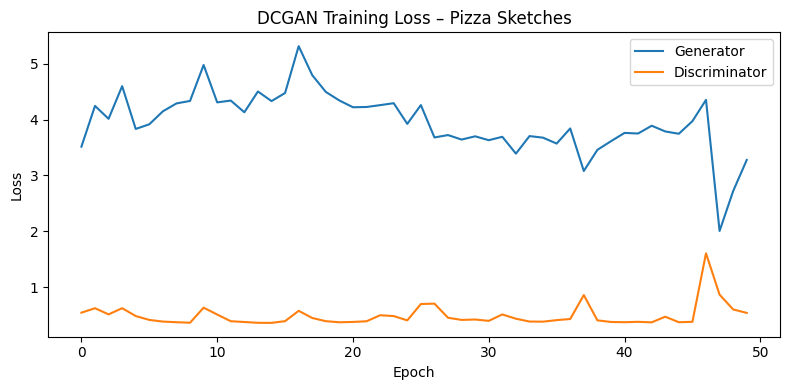

In [57]:
# Loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g_losses, label="Generator")
ax.plot(d_losses, label="Discriminator")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("DCGAN Training Loss – Pizza Sketches")
ax.legend(); fig.tight_layout()
fig.savefig("pizza_loss_curve.png", dpi=150)
plt.show()

***2.3.7 Real vs Synthetic sketches***

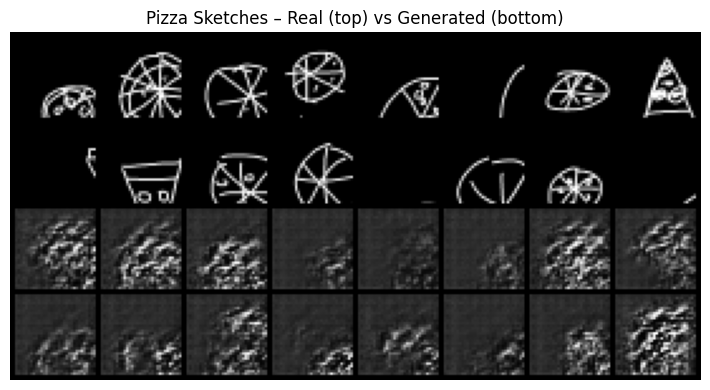

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

In [59]:
G.eval()
with torch.no_grad():
    fake_samples = G(z_fixed).cpu()

real_samples = next(iter(train_loader_pizza))[0][:16].cpu()

def to_grid(t):
    return ((t + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)

grid = make_grid(torch.cat([to_grid(real_samples), to_grid(fake_samples)]), nrow=8, padding=2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(grid.permute(1, 2, 0))
ax.axis("off")
ax.set_title("Pizza Sketches – Real (top) vs Generated (bottom)")
fig.tight_layout()
fig.savefig("pizza_real_vs_fake.png", dpi=150)
plt.show()
G.train()

***2.3.8 4x4 generated samples***

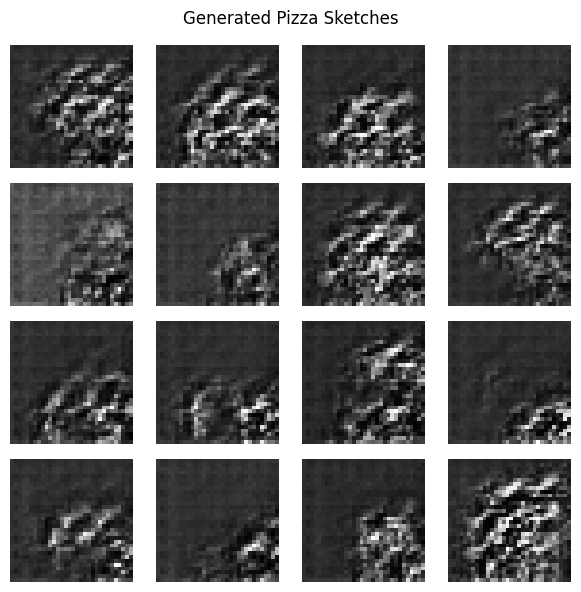

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

In [60]:
G.eval()
with torch.no_grad():
    samples = ((G(z_fixed).cpu() + 1) / 2).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for ax, img in zip(axes.flatten(), samples):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")
fig.suptitle("Generated Pizza Sketches")
fig.tight_layout()
fig.savefig("pizza_generated.png", dpi=150)
plt.show()
G.train()

***2.3.9 FID score***

In [61]:
def save_images_for_fid(tensor, folder, n=1000):
    os.makedirs(folder, exist_ok=True)
    imgs = ((tensor[:n] + 1) / 2).clamp(0, 1).repeat(1, 3, 1, 1)
    imgs = torch.stack([resize(img, [299, 299]) for img in imgs])
    for i, img in enumerate(imgs):
        save_image(img, f"{folder}/{i:04d}.png")

# save real images
save_images_for_fid(pizza_tensor[:1000], "fid_real")

# generate and save fake images
G.eval()
fake_batches = []
with torch.no_grad():
    for _ in range(1000 // 64 + 1):
        z = torch.randn(64, z_dim, 1, 1, device=device)
        fake_batches.append(G(z).cpu())
all_fake = torch.cat(fake_batches)[:1000]
save_images_for_fid(all_fake, "fid_fake")

# calculate FID directly — no subprocess, no fragile string parsing
print("Calculating FID...")
pizza_fid = calculate_fid_given_paths(
    ["fid_real", "fid_fake"],
    batch_size=50,
    device=device,
    dims=2048
)
print(f"Pizza FID Score: {pizza_fid:.2f}")
G.train()

Calculating FID...


100%|███████████████████████████████████████████| 20/20 [00:09<00:00,  2.18it/s]


Pizza FID Score: 299.82


Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

***2.3.10 Sample generation from other QuickDraw categories (cat, house)***


Training on: cat
  [cat] Epoch 10/50 | D: 0.3897 | G: 4.4516
  [cat] Epoch 20/50 | D: 0.3907 | G: 4.1877
  [cat] Epoch 30/50 | D: 0.4032 | G: 3.7865
  [cat] Epoch 40/50 | D: 0.8699 | G: 3.5291
  [cat] Epoch 50/50 | D: 0.3841 | G: 3.7594


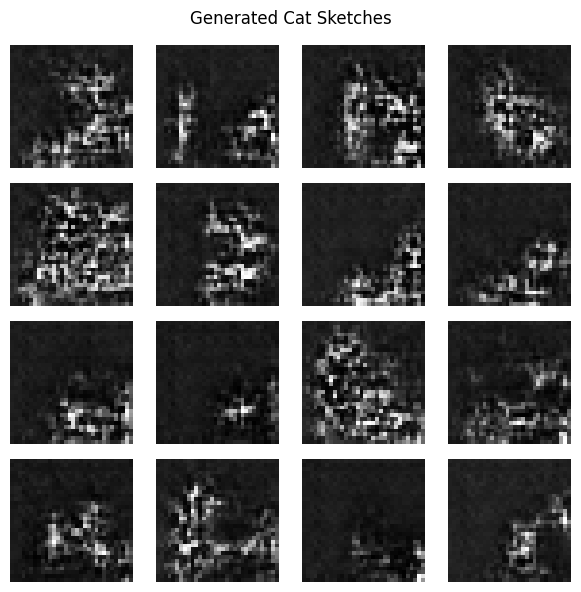


Training on: house
  [house] Epoch 10/50 | D: 0.3682 | G: 4.3696
  [house] Epoch 20/50 | D: 0.3997 | G: 3.9428
  [house] Epoch 30/50 | D: 0.3640 | G: 3.9288
  [house] Epoch 40/50 | D: 0.3630 | G: 3.9656
  [house] Epoch 50/50 | D: 0.3672 | G: 4.1565


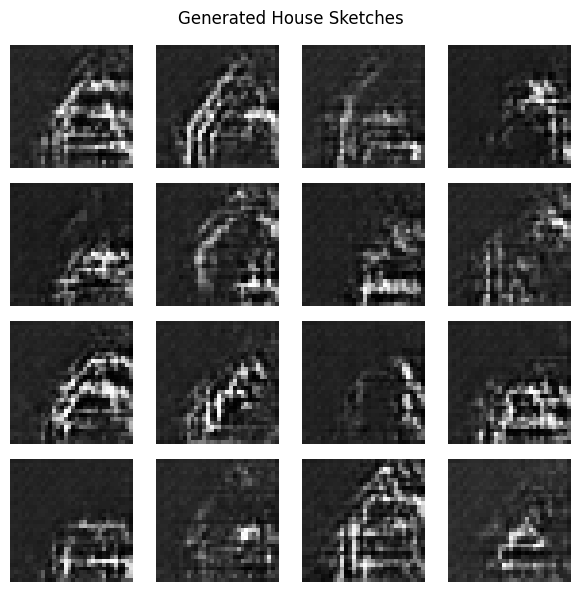

In [62]:
categories = ["cat", "house"]

results = {}
for cat in categories:
    print(f"\n{'='*50}")
    print(f"Training on: {cat}")
    print(f"{'='*50}")

    # download
    url = f"https://storage.googleapis.com/quickdraw_dataset/full/raw/{cat}.ndjson"
    path = f"data/{cat}.ndjson"
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)

    # load
    drawings = []
    with open(path) as f:
        for line in f:
            s = json.loads(line)
            if s.get("recognized"):
                drawings.append(s["drawing"])
            if len(drawings) >= 5000:
                break

    # preprocess
    imgs = []
    for d in drawings:
        img = draw_to_image(d)
        if img.max() > 0:
            img = (img.astype(np.float32) / 127.5) - 1.0
            imgs.append(img)

    tensor = torch.tensor(np.array(imgs)).unsqueeze(1)
    loader = DataLoader(TensorDataset(tensor), batch_size=64, shuffle=True,
                        num_workers=min(4, os.cpu_count()), pin_memory=True,
                        prefetch_factor=2, persistent_workers=True)

    # fresh models
    G_cat = Generator().to(device)
    D_cat = Discriminator().to(device)
    g_opt_c = optim.Adam(G_cat.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_opt_c = optim.Adam(D_cat.parameters(), lr=0.0002, betas=(0.5, 0.999))

    z_cat   = torch.randn(16, z_dim, 1, 1, device=device)
    g_l, d_l = [], []

    for epoch in range(50):
        G_cat.train(); D_cat.train()
        g_sum = d_sum = 0.0
        for (real,) in loader:
            real = real.to(device, non_blocking=True)
            bs   = real.size(0)
            rl   = torch.full((bs, 1), 0.9, device=device)
            fl   = torch.zeros(bs, 1, device=device)

            with torch.no_grad():
                fake = G_cat(torch.randn(bs, z_dim, 1, 1, device=device))
            d_loss = criterion(D_cat(real), rl) + criterion(D_cat(fake), fl)
            d_opt_c.zero_grad(set_to_none=True); d_loss.backward(); d_opt_c.step()

            fake   = G_cat(torch.randn(bs, z_dim, 1, 1, device=device))
            g_loss = criterion(D_cat(fake), rl)
            g_opt_c.zero_grad(set_to_none=True); g_loss.backward(); g_opt_c.step()

            g_sum += g_loss.item(); d_sum += d_loss.item()

        g_l.append(g_sum / len(loader))
        d_l.append(d_sum / len(loader))
        if (epoch + 1) % 10 == 0:
            print(f"  [{cat}] Epoch {epoch+1}/50 | D: {d_l[-1]:.4f} | G: {g_l[-1]:.4f}")

    results[cat] = {"g_losses": g_l, "d_losses": d_l, "G": G_cat}

    # visualise generated samples
    G_cat.eval()
    with torch.no_grad():
        gen = ((G_cat(z_cat).cpu() + 1) / 2).clamp(0, 1)

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img in zip(axes.flatten(), gen):
        ax.imshow(img.squeeze(), cmap="gray"); ax.axis("off")
    fig.suptitle(f"Generated {cat.capitalize()} Sketches")
    fig.tight_layout()
    fig.savefig(f"{cat}_generated.png", dpi=150)
    plt.show()
    G_cat.train()

***2.3.11 Loss curve comparison across categories***

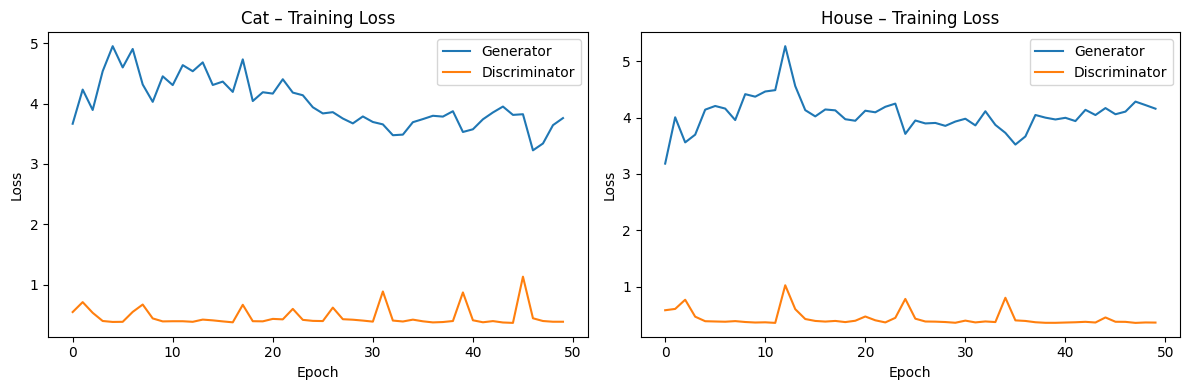

In [63]:
fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories), 4))

for ax, cat in zip(axes, categories):
    ax.plot(results[cat]["g_losses"], label="Generator")
    ax.plot(results[cat]["d_losses"], label="Discriminator")
    ax.set_title(f"{cat.capitalize()} – Training Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend()

fig.tight_layout()
fig.savefig("category_loss_comparison.png", dpi=150)
plt.show()

***2.3.12 Summary for QuickDraw categories***

In [64]:
print(f"\n{'Category':<12} {'Final G Loss':>14} {'Final D Loss':>14} {'FID':>10}")
print("-" * 54)
print(f"{'Pizza':<12} {pizza_final_g_loss:>14.4f} {pizza_final_d_loss:>14.4f} {pizza_fid:>10.2f}")
for cat in categories:
    g_final = results[cat]["g_losses"][-1]
    d_final = results[cat]["d_losses"][-1]
    print(f"{cat.capitalize():<12} {g_final:>14.4f} {d_final:>14.4f} {'N/A':>10}")


Category       Final G Loss   Final D Loss        FID
------------------------------------------------------
Pizza                3.2768         0.5414     299.82
Cat                  3.7594         0.3841        N/A
House                4.1565         0.3672        N/A


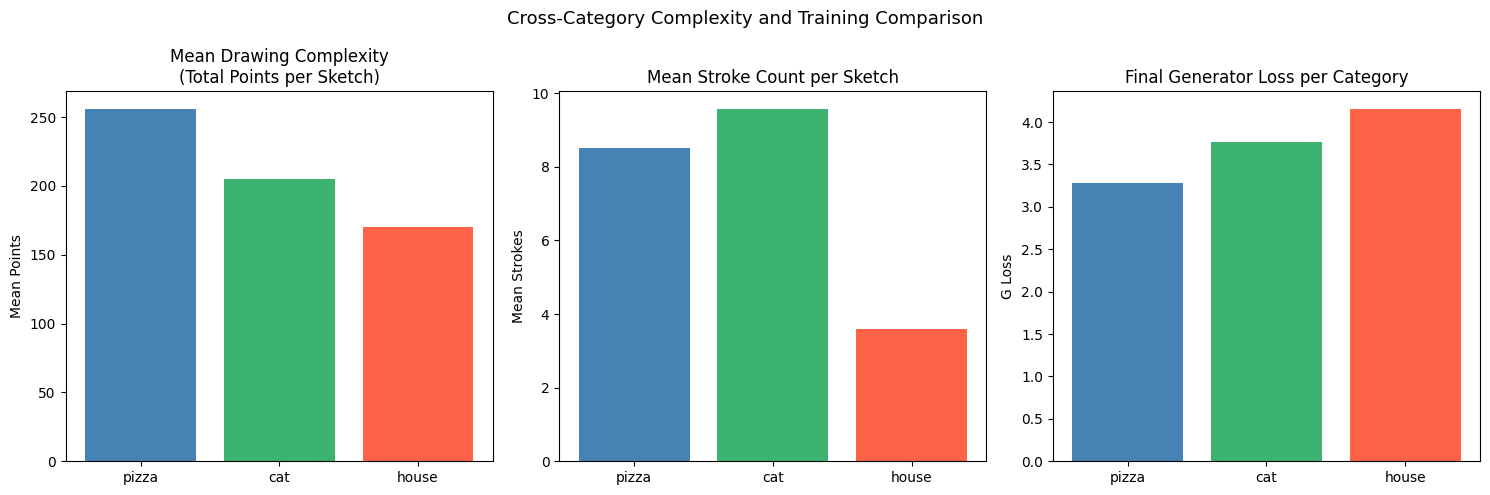


Category     Mean Strokes   Mean Points   Final G Loss   Final D Loss
--------------------------------------------------------------------
pizza                 8.5         256.0         3.2768         0.5414
cat                   9.6         204.7         3.7594         0.3841
house                 3.6         170.4         4.1565         0.3672


In [65]:
# compare complexity of categories and discuss model performance
categories_all = ["pizza"] + categories

# collect stroke and point stats for each category
all_drawings = {"pizza": pizza_drawings}
for cat in categories:
    drawings = []
    with open(f"data/{cat}.ndjson") as f:
        for line in f:
            s = json.loads(line)
            if s.get("recognized"):
                drawings.append(s["drawing"])
            if len(drawings) >= 5000:
                break
    all_drawings[cat] = drawings

complexity_stats = {}
for cat, drawings in all_drawings.items():
    strokes = [len(d) for d in drawings]
    points  = [sum(len(s[0]) for s in d) for d in drawings]
    complexity_stats[cat] = {
        "mean_strokes": np.mean(strokes),
        "mean_points":  np.mean(points),
        "final_g_loss": pizza_final_g_loss if cat == "pizza" else results[cat]["g_losses"][-1],
        "final_d_loss": pizza_final_d_loss if cat == "pizza" else results[cat]["d_losses"][-1],
    }

# complexity vs final G loss bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cats        = list(complexity_stats.keys())
mean_pts    = [complexity_stats[c]["mean_points"]  for c in cats]
mean_str    = [complexity_stats[c]["mean_strokes"] for c in cats]
final_gloss = [complexity_stats[c]["final_g_loss"] for c in cats]

axes[0].bar(cats, mean_pts, color=['steelblue', 'mediumseagreen', 'tomato'])
axes[0].set_title("Mean Drawing Complexity\n(Total Points per Sketch)")
axes[0].set_ylabel("Mean Points")

axes[1].bar(cats, mean_str, color=['steelblue', 'mediumseagreen', 'tomato'])
axes[1].set_title("Mean Stroke Count per Sketch")
axes[1].set_ylabel("Mean Strokes")

axes[2].bar(cats, final_gloss, color=['steelblue', 'mediumseagreen', 'tomato'])
axes[2].set_title("Final Generator Loss per Category")
axes[2].set_ylabel("G Loss")

plt.suptitle("Cross-Category Complexity and Training Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("category_complexity_comparison.png", dpi=150)
plt.show()

# print summary table
print(f"\n{'Category':<10} {'Mean Strokes':>14} {'Mean Points':>13} {'Final G Loss':>14} {'Final D Loss':>14}")
print("-" * 68)
for cat in cats:
    s = complexity_stats[cat]
    print(f"{cat:<10} {s['mean_strokes']:>14.1f} {s['mean_points']:>13.1f} {s['final_g_loss']:>14.4f} {s['final_d_loss']:>14.4f}")